<a href="https://colab.research.google.com/github/bhavvvyy/FIFA-19-Data-Analysis/blob/main/FIFA_19_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Import Libraries and Load Data
This step imports essential tools like pandas and tries loading the dataset from the URL so we can inspect its structure.

In [2]:
# Import pandas for working with data tables
import pandas as pd
# Import numpy for handling numerical operations
import numpy as np
# Import matplotlib for basic plotting
import matplotlib.pyplot as plt
# Import seaborn for beautiful statistical plots
import seaborn as sns
# Import files from google.colab to handle manual uploads if needed
from google.colab import files

# Save the raw URL of the FIFA 19 dataset to a variable
dataset_url = "https://raw.githubusercontent.com/bhavvvyy/FIFA-19-Data-Analysis/main/kl.csv"

# Try to load the dataset directly from the GitHub URL using latin1 encoding
try:
    # Read the CSV file into a pandas DataFrame using latin1 to handle special characters
    df = pd.read_csv(dataset_url, encoding='latin1')
    # Print a success message if it works
    print("Dataset loaded successfully from the URL!")
# Catch any error if loading from the URL fails
except Exception as error:
    # Print the specific error message to understand what failed
    print("Failed to load from URL:", error)
    # Print instruction to upload the file manually
    print("Please upload 'kl.csv' manually below:")
    # Trigger the file upload dialog in Google Colab
    uploaded = files.upload()
    # Load the uploaded file name into a variable
    uploaded_filename = list(uploaded.keys())[0]
    # Read the manually uploaded CSV file using latin1 encoding
    df = pd.read_csv(uploaded_filename, encoding='latin1')

# Display the first five rows of the dataset to verify the contents
display(df.head())

Dataset loaded successfully from the URL!


,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31.0,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94.0,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226.5M
1,1,20801,Cristiano Ronaldo,33.0,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94.0,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127.1M
2,2,190871,Neymar Jr,26.0,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92.0,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228.1M
3,3,193080,De Gea,27.0,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91.0,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138.6M
4,4,192985,K. De Bruyne,27.0,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196.4M


### Step 2: Explore the Dataset
This step runs basic exploration commands to understand the size, data types, missing values, and column contents.

In [3]:
# Print the number of rows and columns in the dataset
print("Dataset Shape:", df.shape)
# Display detailed column structures and data types
df.info()
# Show summary statistics for numerical columns
display(df.describe())
# Print value counts of some text columns like 'Preferred Foot'
print(df['Preferred Foot'].value_counts(dropna=False))
# Print value counts of the 'Position' text column
print(df['Position'].value_counts(dropna=False))

Dataset Shape: (18207, 89)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 89 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                18207 non-null  int64  
 1   ID                        18207 non-null  int64  
 2   Name                      18207 non-null  object 
 3   Age                       18206 non-null  float64
 4   Photo                     18207 non-null  object 
 5   Nationality               18207 non-null  object 
 6   Flag                      18207 non-null  object 
 7   Overall                   18206 non-null  float64
 8   Potential                 18207 non-null  int64  
 9   Club                      17966 non-null  object 
 10  Club Logo                 18207 non-null  object 
 11  Value                     18207 non-null  object 
 12  Wage                      18207 non-null  object 
 13  Special                   18207 no

,Unnamed: 0,ID,Age,Overall,Potential,Special,International Reputation,Weak Foot,Skill Moves,Jersey Number,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
count,18207.000000,18207.000000,18206.000000,18206.000000,18207.000000,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,9103.000000,214298.338606,25.122048,66.237449,71.307299,1597.809908,1.113222,2.947299,2.361308,19.546096,...,48.548598,58.648274,47.281623,47.697836,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887
std,5256.052511,29965.244204,4.670022,6.907059,6.136496,272.586016,0.394031,0.660456,0.756164,15.947765,...,15.704053,11.436133,19.904397,21.664004,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119
min,0.000000,16.000000,16.000000,46.000000,48.000000,731.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4551.500000,200315.500000,21.000000,62.000000,67.000000,1457.000000,1.000000,3.000000,2.000000,8.000000,...,39.000000,51.000000,30.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,9103.000000,221759.000000,25.000000,66.000000,71.000000,1635.000000,1.000000,3.000000,2.000000,17.000000,...,49.000000,60.000000,53.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,13654.500000,236529.500000,28.000000,71.000000,75.000000,1787.000000,1.000000,3.000000,3.000000,26.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,18206.000000,246620.000000,45.000000,94.000000,95.000000,2346.000000,5.000000,5.000000,5.000000,99.000000,...,92.000000,96.000000,94.000000,93.000000,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000


Preferred Foot
Right    13948
Left      4211
NaN         48
Name: count, dtype: int64
Position
ST     2152
GK     2025
CB     1778
CM     1394
LB     1322
RB     1291
RM     1124
LM     1095
CAM     958
CDM     948
RCB     662
LCB     648
LCM     395
RCM     391
LW      381
RW      370
RDM     248
LDM     243
LS      207
RS      203
RWB      87
LWB      78
CF       74
NaN      60
LAM      21
RAM      21
RF       16
LF       15
Name: count, dtype: int64


### Step 3: Handle Missing Values
This step identifies missing data, plots a bar chart of the missing counts, drops columns missing over 50% of their values, and fills the remaining missing entries.

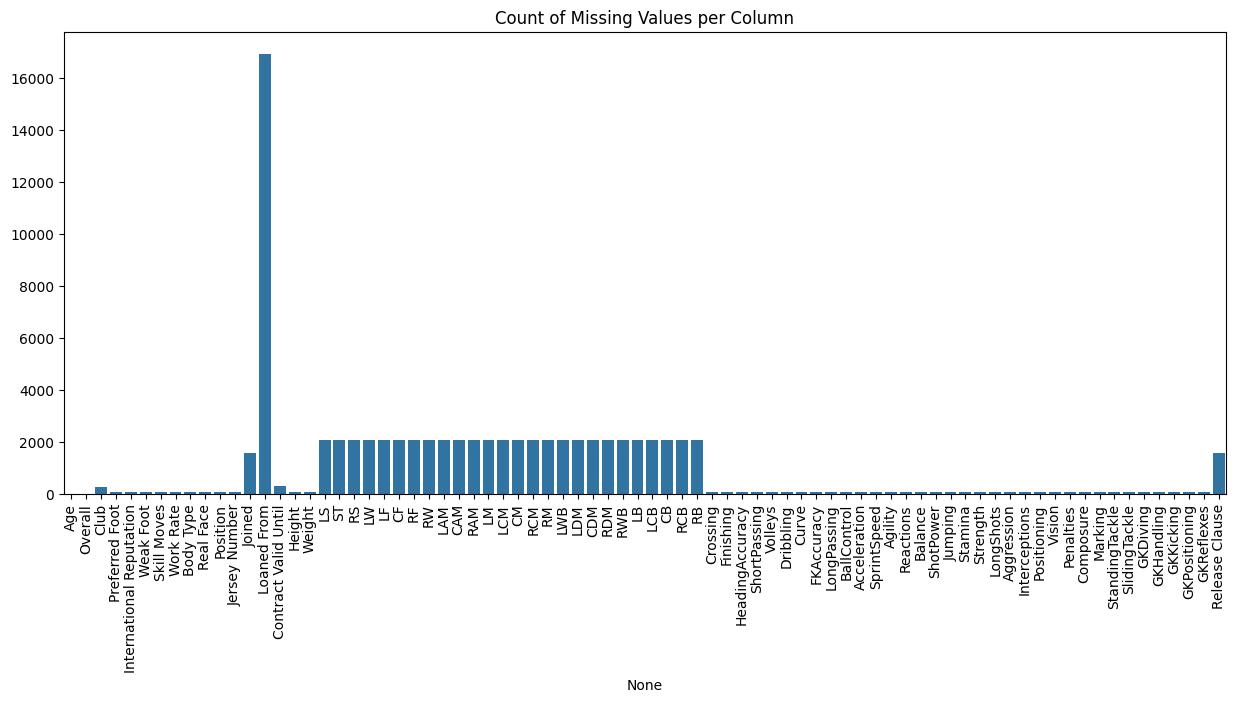

Columns with >50% missing values:
- Loaned From: 93.06% missing
  Dropped column: Loaned From
Total missing values remaining: 0


In [4]:
# Calculate the number of missing values in each column
missing_counts = df.isnull().sum()
# Filter out columns that do not have any missing values
missing_cols = missing_counts[missing_counts > 0]

# Check if there are columns with missing values to plot
if not missing_cols.empty:
    # Create a figure for plotting with a specific size
    plt.figure(figsize=(15, 6))
    # Create a bar plot showing the counts of missing values
    sns.barplot(x=missing_cols.index, y=missing_cols.values)
    # Rotate the column names on the X-axis for readability
    plt.xticks(rotation=90)
    # Set the title of the plot
    plt.title("Count of Missing Values per Column")
    # Display the completed plot
    plt.show()

# Print a list of columns with more than 50% missing values
print("Columns with >50% missing values:")
# Loop through each column in the DataFrame
for col in df.columns:
    # Calculate the percentage of missing values for the column
    pct_missing = df[col].isnull().mean()
    # If the missing percentage is greater than 50%, print it and drop it
    if pct_missing > 0.50:
        # Print the column name and its percentage of missing values
        print(f"- {col}: {pct_missing * 100:.2f}% missing")
        # Drop the column from the DataFrame in-place
        df.drop(columns=[col], inplace=True)
        # Print a message confirming the column was dropped
        print(f"  Dropped column: {col}")

# Loop through each column in the DataFrame to impute remaining missing values
for col in df.columns:
    # Check if the column still has any missing values
    if df[col].isnull().any():
        # If the column data type is numeric (float or integer)
        if df[col].dtype in ['float64', 'int64']:
            # Calculate the median of the column
            col_median = df[col].median()
            # Fill the missing values in this column with its median
            df[col] = df[col].fillna(col_median)
        # If the column data type is a text/category (object)
        else:
            # Get the most common value (mode) of the column
            col_mode = df[col].mode()[0]
            # Fill the missing values in this column with its mode
            df[col] = df[col].fillna(col_mode)

# Recalculate the missing values in each column to verify the cleaning
new_missing_counts = df.isnull().sum()
# Print the total number of missing values remaining in the whole dataset
print("Total missing values remaining:", new_missing_counts.sum())

### Step 4: Remove Duplicates
This step checks for completely identical rows of player data in the dataset, counts them, and deletes them if any exist.

In [5]:
# Calculate the number of duplicate rows currently in the dataset
duplicate_count = df.duplicated().sum()
# Print the total number of duplicate rows found
print("Number of duplicate rows found:", duplicate_count)
# Drop the duplicate rows in-place to update the dataset
df.drop_duplicates(inplace=True)
# Print the count of duplicates that were successfully removed
print("Number of duplicate rows removed:", duplicate_count)

Number of duplicate rows found: 0
Number of duplicate rows removed: 0


### Step 5: Fix Data Types and Odd Values
This step drops unnecessary index and ID columns, and cleans financial text columns like Value, Wage, and Release Clause into clean numeric floats.

In [6]:
# Drop the columns 'Unnamed: 0' and 'ID' because they are useless row identifiers
df.drop(columns=['Unnamed: 0', 'ID'], inplace=True)

# Define a helper function to convert financial text strings to numeric floats in millions
def clean_money(val):
    # Convert the value to a string just in case it is not already
    val = str(val)
    # Remove the Euro symbol character from the string
    val = val.replace('\u0080', '')
    # Check if 'M' representing Millions is in the string value
    if 'M' in val:
        # Remove the 'M' letter and convert the rest to a float
        return float(val.replace('M', ''))
    # Check if 'K' representing Thousands is in the string value
    elif 'K' in val:
        # Remove the 'K', convert to float, and divide by 1000 to express in millions
        return float(val.replace('K', '')) / 1000.0
    # Return 0.0 if the string is empty or has no numeric indicators
    return 0.0

# Apply the cleaning helper function to convert 'Value' into millions
df['Value'] = df['Value'].apply(clean_money)
# Apply the cleaning helper function to convert 'Wage' into millions
df['Wage'] = df['Wage'].apply(clean_money)
# Apply the cleaning helper function to convert 'Release Clause' into millions
df['Release Clause'] = df['Release Clause'].apply(clean_money)

# Print the data types of the cleaned financial columns to verify they are float64
print(df[['Value', 'Wage', 'Release Clause']].dtypes)
# Display the top five rows of these columns to inspect the cleaned values
display(df[['Value', 'Wage', 'Release Clause']].head())

Value             float64
Wage              float64
Release Clause    float64
dtype: object


,Value,Wage,Release Clause
0,110.5,0.565,226.5
1,77.0,0.405,127.1
2,118.5,0.290,228.1
3,72.0,0.260,138.6
4,102.0,0.355,196.4


### Step 6: Handle Outliers via Capping
This step saves a copy of the dataframe, shows boxplots of numeric columns, and uses a helper function to cap extreme values outside the IQR bounds.

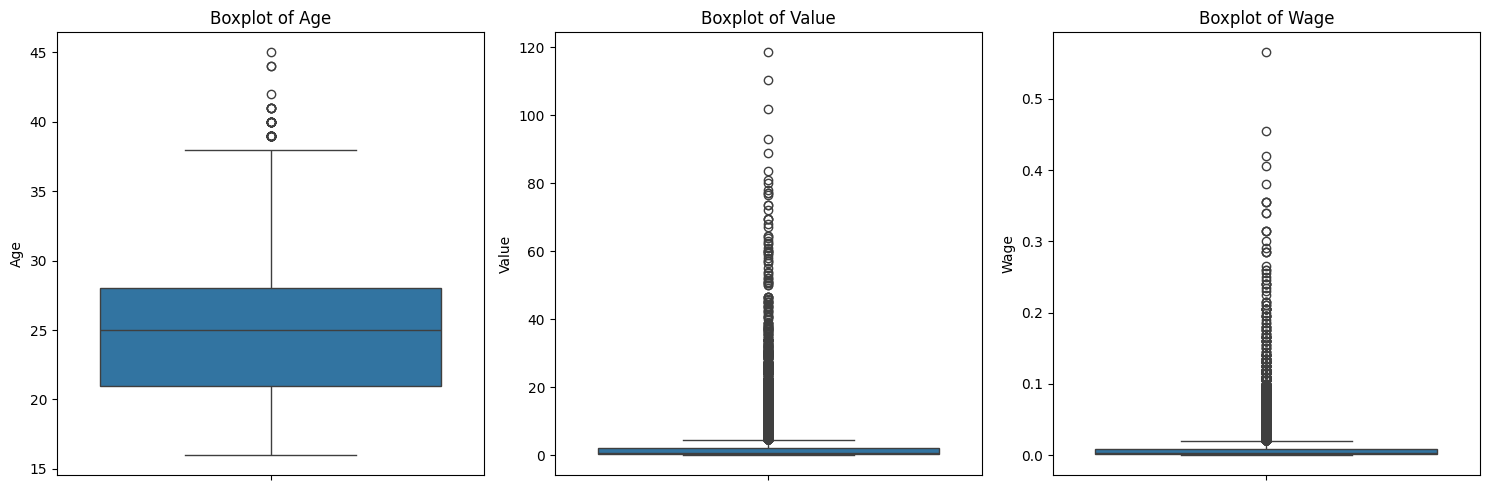

Age: Found and capped 47 outliers. Limits used: [10.50, 38.50]
Value: Found and capped 2487 outliers. Limits used: [-2.25, 4.55]
Wage: Found and capped 2142 outliers. Limits used: [-0.01, 0.02]


In [7]:
# Keep a complete copy of the dataframe before modifying outliers
df_before = df.copy()

# Create a list of the main numeric columns we want to check for outliers
numeric_cols = ['Age', 'Value', 'Wage']

# Set up a plotting figure to display box plots side-by-side
plt.figure(figsize=(15, 5))
# Loop through each column to draw its boxplot
for idx, col in enumerate(numeric_cols):
    # Create a subplot in a 1-row, 3-column layout
    plt.subplot(1, 3, idx + 1)
    # Generate a boxplot for the current column using seaborn
    sns.boxplot(y=df[col])
    # Set the title of the individual boxplot
    plt.title(f"Boxplot of {col}")
# Adjust the layout elements so they do not overlap
plt.tight_layout()
# Show the completed boxplots
plt.show()

# Define a simple helper function to cap outliers in a column using IQR limits
def cap_outliers(data_series):
    # Calculate the 25th percentile (Q1) of the column data
    q1 = data_series.quantile(0.25)
    # Calculate the 75th percentile (Q3) of the column data
    q3 = data_series.quantile(0.75)
    # Calculate the Interquartile Range (IQR)
    iqr = q3 - q1
    # Define the lower limit for normal values
    lower_limit = q1 - 1.5 * iqr
    # Define the upper limit for normal values
    upper_limit = q3 + 1.5 * iqr
    # Count how many values are below the lower limit
    below_count = (data_series < lower_limit).sum()
    # Count how many values are above the upper limit
    above_count = (data_series > upper_limit).sum()
    # Calculate the total number of outliers in this column
    total_outliers = below_count + above_count
    # Cap the values outside limits using clip in-place
    capped_series = data_series.clip(lower_limit, upper_limit)
    # Return the capped series, total count, lower limit, and upper limit
    return capped_series, total_outliers, lower_limit, upper_limit

# Loop through each of our target numeric columns to apply the capping
for col in numeric_cols:
    # Call our helper function and store the outputs
    df[col], count, low, high = cap_outliers(df[col])
    # Print the summary of outlier capping for the column
    print(f"{col}: Found and capped {count} outliers. Limits used: [{low:.2f}, {high:.2f}]")

### Step 7: Compare Before vs After Capping
This step creates side-by-side box plots for Age, Value, and Wage to verify that all outliers have been successfully capped.

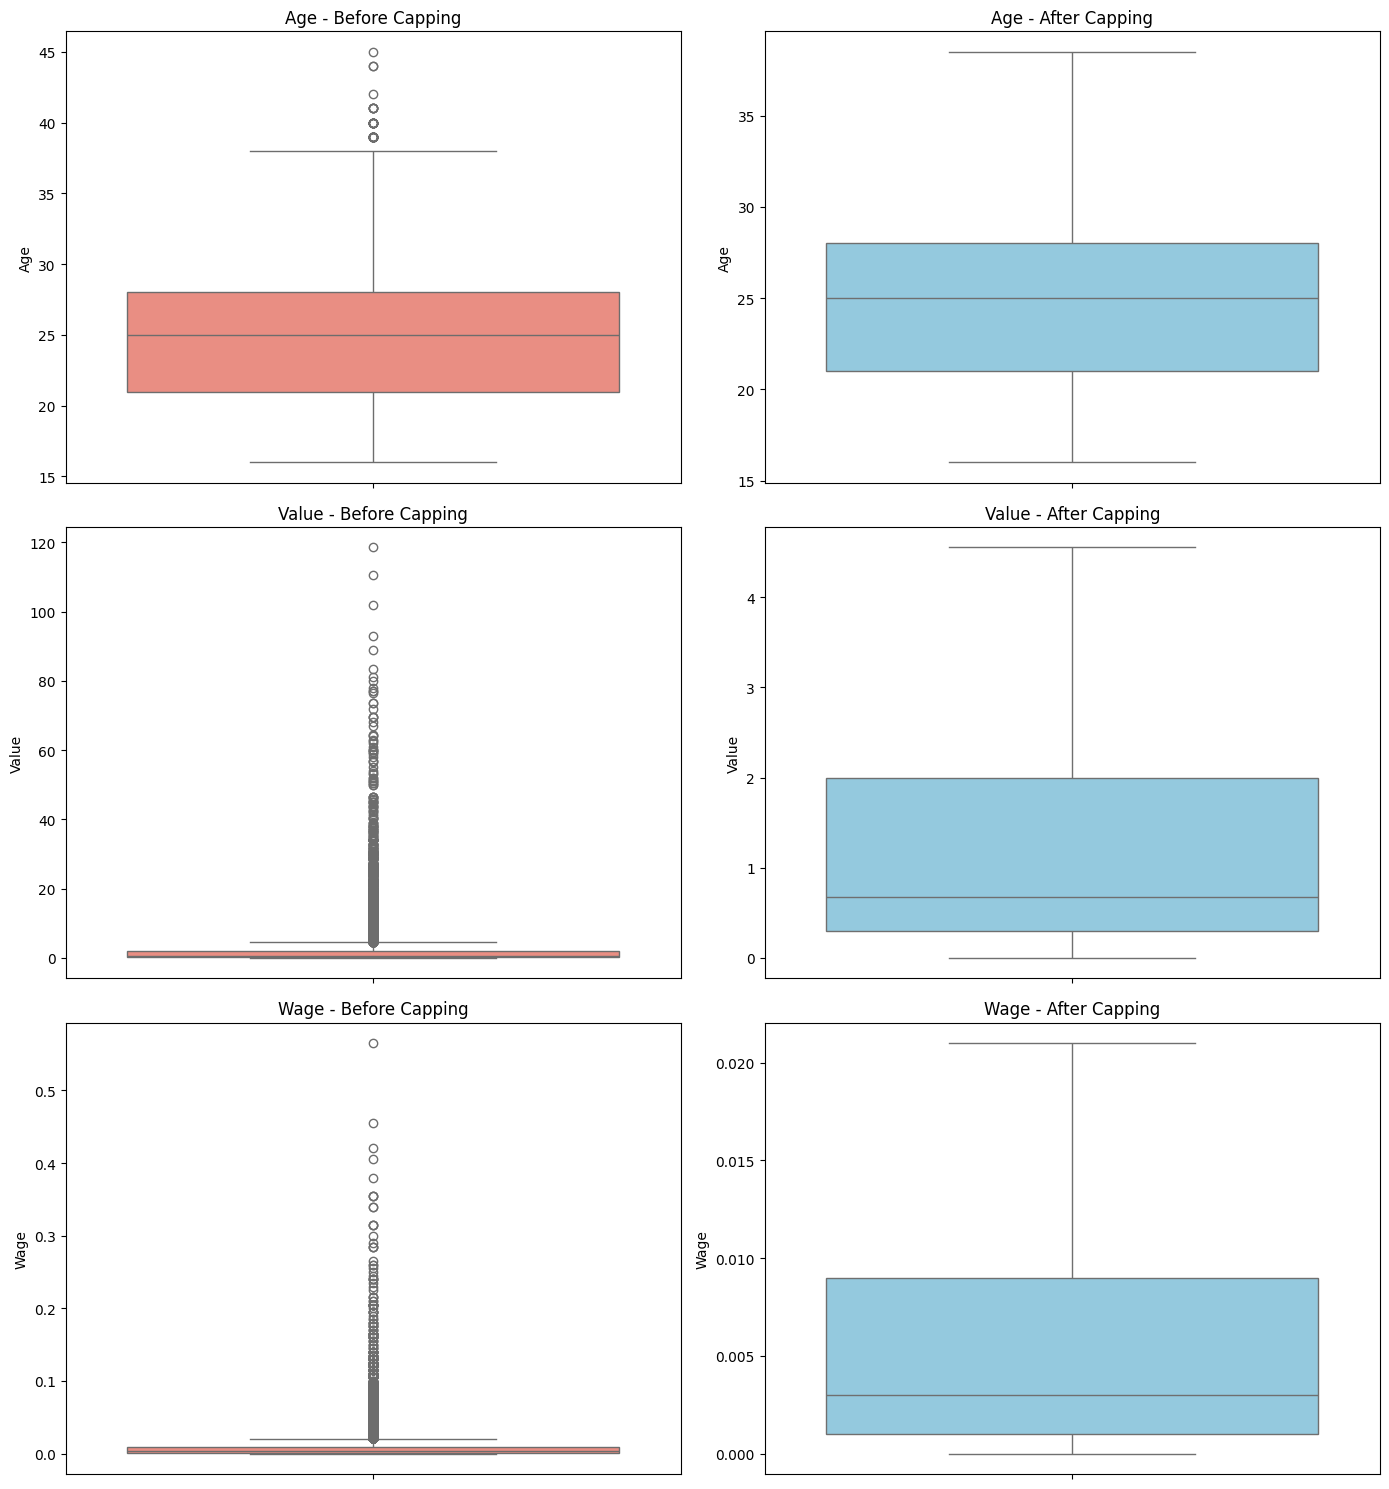

In [8]:
# Create a list of the numeric columns that we just capped
changed_cols = ['Age', 'Value', 'Wage']

# Create a figure with a layout of 3 rows and 2 columns to compare before vs after
plt.figure(figsize=(14, 15))

# Loop through each changed column by its index
for idx, col in enumerate(changed_cols):
    # Create a subplot for the 'Before' state in the left column of the grid
    plt.subplot(3, 2, 2 * idx + 1)
    # Plot the box plot of the original data from df_before
    sns.boxplot(y=df_before[col], color='salmon')
    # Set a clear title indicating it is the data before capping
    plt.title(f"{col} - Before Capping")

    # Create a subplot for the 'After' state in the right column of the grid
    plt.subplot(3, 2, 2 * idx + 2)
    # Plot the box plot of the capped data from df
    sns.boxplot(y=df[col], color='skyblue')
    # Set a clear title indicating it is the data after capping
    plt.title(f"{col} - After Capping")

# Adjust the spacing between subplots to make the layout neat and readable
plt.tight_layout()
# Render and show the complete comparison figure
plt.show()

### Step 8: Feature Engineering
This step creates a new feature representing a player's growth potential by subtracting their current overall rating from their maximum potential rating.

In [9]:
# Calculate the difference between Potential and Overall to get the remaining growth
df['Growth_Potential'] = df['Potential'] - df['Overall']

# Create a list of the rating columns plus our newly engineered feature
rating_columns = ['Name', 'Overall', 'Potential', 'Growth_Potential']

# Display the top five rows of these columns to inspect the new feature
display(df[rating_columns].head())

,Name,Overall,Potential,Growth_Potential
0,L. Messi,94.0,94,0.0
1,Cristiano Ronaldo,94.0,94,0.0
2,Neymar Jr,92.0,93,1.0
3,De Gea,91.0,93,2.0
4,K. De Bruyne,91.0,92,1.0


### Step 9: Exploratory Data Analysis (EDA)
This step visualizes the relationship between a player's Overall rating and their market Value, colored by their Age.

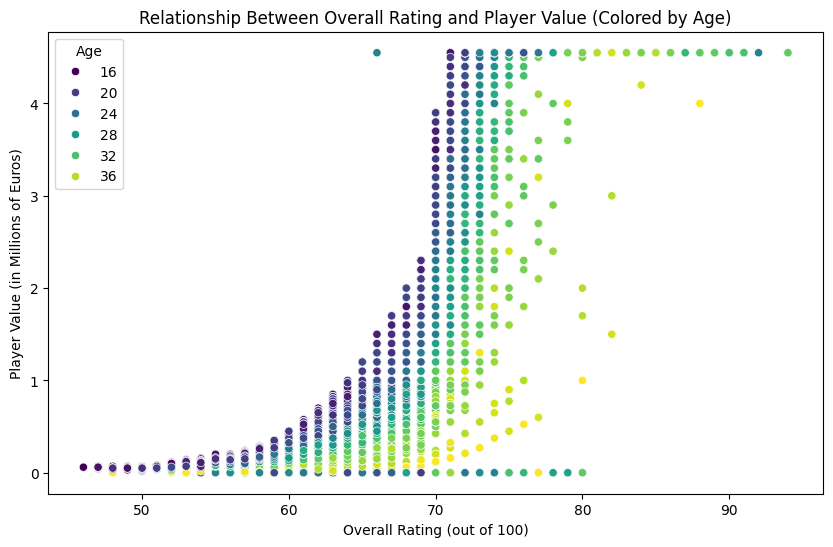

In [10]:
# Set up a figure with a standard display size
plt.figure(figsize=(10, 6))

# Create a scatter plot of Overall versus Value, using Age as the color scale
sns.scatterplot(data=df, x='Overall', y='Value', hue='Age', palette='viridis')

# Add a clear title to explain the purpose of the plot
plt.title("Relationship Between Overall Rating and Player Value (Colored by Age)")
# Label the horizontal axis with units
plt.xlabel("Overall Rating (out of 100)")
# Label the vertical axis with units
plt.ylabel("Player Value (in Millions of Euros)")

# Render and display the completed scatter plot
plt.show()

### Step 10: Save the Cleaned Dataset
This step saves the cleaned DataFrame to a new CSV file without row indexes so that it can be easily shared or used in future projects.

In [11]:
# Export the cleaned DataFrame to a new CSV file on disk
df.to_csv('FIFA19_cleaned.csv', index=False)

# Print a message confirming that the file has been saved
print("Your cleaned dataset was successfully saved as 'FIFA19_cleaned.csv'!")

Your cleaned dataset was successfully saved as 'FIFA19_cleaned.csv'!


### Step 11: Download the Cleaned Dataset
This step uses Google Colab helper functions to download the final cleaned file directly to your local computer.

In [12]:
# Import the colab files module to allow browser downloads
from google.colab import files

# Trigger the download of the cleaned CSV file to your local computer
files.download('FIFA19_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>